In [1]:
# Environment & Imports (FINAL)

# Core libraries
import numpy as np
import math
import os
import sys
import time

# Geometry
from shapely.geometry import Polygon
from shapely import affinity
from shapely.strtree import STRtree
import shapely.wkt

# Plotting (optional, safe to keep)
import matplotlib.pyplot as plt

# NMSLIB (Weighted Jaccard)
import nmslib

# Multiprocessing (Windows-safe if guarded later)
from multiprocessing import Process

# -------------------------------------------------
# Add local lib folder (../lib relative to notebook)
# -------------------------------------------------
LIB_PATH = os.path.abspath(os.path.join(os.getcwd(), "lib"))
sys.path.insert(0, LIB_PATH)

import wkthelper
from quadtree import quadtree
from grid import grid

# -------------------------------------------------
# Sanity checks (IMPORTANT)
# -------------------------------------------------
print("Python executable:", sys.executable)
print("Python version   :", sys.version)
print("NMSLIB init OK   :", hasattr(nmslib, "init"))
print("Local lib loaded :", "wkthelper" in sys.modules)

Python executable: C:\Users\keyur\anaconda3\envs\skyline\python.exe
Python version   : 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
NMSLIB init OK   : True
Local lib loaded : True


In [3]:
# Cell 2: Load Skyline Encoded Vectors

ENCODING_PATH = os.path.join(os.getcwd(), "encodedData", "skyline")

print("Encoding path:", ENCODING_PATH)

# -------------------------------------------------
# Helper: read a single encoding file
# -------------------------------------------------
def readEncodeFileToArray(file_path):
    return np.loadtxt(file_path, dtype=float).tolist()

# -------------------------------------------------
# Helper: load all encoding files safely
# -------------------------------------------------
def readAllSparseArray(path):
    files = [
        f for f in os.listdir(path)
        if f.endswith(".txt")
    ]
    files.sort()  # safe even if only one file

    vectors = []
    for f in files:
        full_path = os.path.join(path, f)
        vectors.extend(readEncodeFileToArray(full_path))

    return vectors

# -------------------------------------------------
# Load encodings
# -------------------------------------------------
all_vectors = readAllSparseArray(ENCODING_PATH)

print("Total vectors loaded:", len(all_vectors))

# -------------------------------------------------
# Split into data / query (same as ground truth logic)
# -------------------------------------------------
data_percent = 0.8
total = len(all_vectors)

data_end = math.ceil(total * data_percent)

data_vectors  = all_vectors[:data_end]
query_vectors = all_vectors[data_end:]

print("Data vectors :", len(data_vectors))
print("Query vectors:", len(query_vectors))

Encoding path: C:\Users\keyur\Downloads\skyline_project\ssEncoding\encodedData\skyline
Total vectors loaded: 120
Data vectors : 96
Query vectors: 24


In [5]:
import sys
print("Python executable:")
print(sys.executable)

import nmslib
print("nmslib module path:")
print(nmslib.__file__)
print("Has init:", hasattr(nmslib, "init"))


Python executable:
C:\Users\keyur\anaconda3\envs\skyline\python.exe
nmslib module path:
C:\Users\keyur\anaconda3\envs\skyline\lib\site-packages\nmslib.cp39-win_amd64.pyd
Has init: True


In [7]:
# Cell 3: Build Weighted Jaccard Index (SAFE)

import nmslib

# Safety check
assert hasattr(nmslib, "init"), (
    "nmslib.init not found.\n"
    "You are NOT using the skyline kernel.\n"
    "Kernel → Change Kernel → Python (skyline)"
)

def createWeightedJaccardIndex(data, M=16, efC=200, threads=4, post=1):
    print("Initializing NMSLIB (WeightedJaccard)...")

    index = nmslib.init(
        method='hnsw',
        space='WeightedJaccard'
    )

    print("Adding data vectors...")
    index.addDataPointBatch(data)

    params = {
        'M': M,
        'efConstruction': efC,
        'indexThreadQty': threads,
        'post': post
    }

    print("Index params:", params)

    start = time.time()
    index.createIndex(params)
    end = time.time()

    print(f"Index created in {end - start:.2f} seconds")
    print(f"Vectors indexed: {len(data)}")

    return index


# Build index
index = createWeightedJaccardIndex(
    data_vectors,
    M=16,
    efC=200,
    threads=4,
    post=1
)


Initializing NMSLIB (WeightedJaccard)...
Adding data vectors...
Index params: {'M': 16, 'efConstruction': 200, 'indexThreadQty': 4, 'post': 1}
Index created in 0.04 seconds
Vectors indexed: 96


In [9]:
# Cell 4: Query the Index

def queryIndex(index, query_vectors, K=10, efS=200, threads=4):
    print("Setting query-time parameters...")
    
    index.setQueryTimeParams({
        'efSearch': efS
    })

    print(f"Running kNN search (K={K}) on {len(query_vectors)} queries...")

    start = time.time()
    nbrs = index.knnQueryBatch(
        query_vectors,
        k=K,
        num_threads=threads
    )
    end = time.time()

    print(f"Total query time: {end - start:.2f} seconds")
    print(f"Avg time per query: {(end - start)/len(query_vectors):.6f} seconds")

    return nbrs


# -------------------------
# Run query
# -------------------------
K = 10          # top-K neighbors
efS = 200       # search accuracy
threads = 4     # SAFE for Windows

neighbors = queryIndex(
    index,
    query_vectors,
    K=K,
    efS=efS,
    threads=threads
)

print("Sample result (first query):")
print("Neighbor IDs :", neighbors[0][0])
print("Distances    :", neighbors[0][1])

Setting query-time parameters...
Running kNN search (K=10) on 24 queries...
Total query time: 0.01 seconds
Avg time per query: 0.000418 seconds
Sample result (first query):
Neighbor IDs : [63 57 67 26 64 93 92 12 68 49]
Distances    : [0.35192704 0.37521678 0.3901701  0.40311015 0.41044527 0.43120503
 0.43138313 0.43289918 0.43332303 0.43409437]


In [11]:
import os

GT_FILE = r"C:\Users\keyur\Downloads\skyline_project\ssEncoding\groundtruth\query-0\similarityMap\similarityMap_0-119"

print("Exists:", os.path.exists(GT_FILE))
print("Is file:", os.path.isfile(GT_FILE))
print("File size (bytes):", os.path.getsize(GT_FILE))


Exists: True
Is file: True
File size (bytes): 3176


In [13]:
# Cell 5: Load Ground Truth (FINAL – extension-safe)

import os

GT_PATH = os.path.join(
    os.getcwd(),
    "groundtruth",
    "query-0",
    "similarityMap"
)

print("Ground truth directory:", GT_PATH)
print("Is directory:", os.path.isdir(GT_PATH))


def readGroundTruthFile(file_path):
    gt = []
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                gt.append([])
            else:
                gt.append([int(x) for x in line.split(", ")])
    return gt


def readAllGroundTruthFiles(folder):
    if not os.path.isdir(folder):
        raise RuntimeError(f" Path is not a directory: {folder}")

    files = sorted([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))   # ← KEY FIX
    ])

    if len(files) == 0:
        raise RuntimeError(" No ground truth files found")

    print(f"Found {len(files)} ground truth file(s):")
    for f in files:
        print("  ", f)

    gt_all = []
    for f in files:
        full_path = os.path.join(folder, f)
        gt_all.extend(readGroundTruthFile(full_path))

    return gt_all


# -------------------------
# Load ground truth
# -------------------------
ground_truth = readAllGroundTruthFiles(GT_PATH)

print("Total ground truth queries:", len(ground_truth))
print("Sample ground truth (first query):", ground_truth[0])

Ground truth directory: C:\Users\keyur\Downloads\skyline_project\ssEncoding\groundtruth\query-0\similarityMap
Is directory: True
Found 1 ground truth file(s):
   similarityMap_0-119
Total ground truth queries: 120
Sample ground truth (first query): [0]


In [15]:
# CELL 6: Query & Recall@K

# ---------- Parameters ----------
K = 10          # top-K neighbors
efS = 100       # efSearch (query-time)
threads = 4     # SAFE for Windows

GT_FILE = r"C:\Users\keyur\Downloads\skyline_project\ssEncoding\groundtruth\query-0\similarityMap\similarityMap_0-119"

print("Using ground truth file:")
print(GT_FILE)

# ---------- Load Ground Truth ----------
def read_ground_truth_file(filepath):
    gt = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line == "":
                gt.append([])
            else:
                gt.append([int(x) for x in line.split(", ")])
    return gt

ground_truth = read_ground_truth_file(GT_FILE)

print("Ground truth queries:", len(ground_truth))
print("Sample GT (first query):", ground_truth[0])


# ---------- Query NMSLIB ----------
print("\nSetting query-time parameters...")
index.setQueryTimeParams({'efSearch': efS})

print("Running kNN queries...")
start = time.time()
nbrs = index.knnQueryBatch(
    query_vectors,
    k=K,
    num_threads=threads
)
end = time.time()

print(f"kNN search time: {end - start:.3f} seconds")


# ---------- Recall Computation ----------
def compute_recall(gt, nbrs, K):
    recall_sum = 0.0
    valid_queries = 0

    for i in range(len(gt)):
        # Skip empty ground truth
        if len(gt[i]) == 0:
            continue

        # Skip if no neighbors returned
        if i >= len(nbrs) or len(nbrs[i]) == 0 or len(nbrs[i][0]) == 0:
            continue

        gt_set = set(gt[i][:K])
        pred_set = set(nbrs[i][0][:K])

        recall_sum += len(gt_set & pred_set) / len(gt_set)
        valid_queries += 1

    if valid_queries == 0:
        return 0.0

    return recall_sum / valid_queries



recall = compute_recall(ground_truth, nbrs, K)
print(f"Recall@{K}: {recall:.4f}")


Using ground truth file:
C:\Users\keyur\Downloads\skyline_project\ssEncoding\groundtruth\query-0\similarityMap\similarityMap_0-119
Ground truth queries: 120
Sample GT (first query): [0]

Setting query-time parameters...
Running kNN queries...
kNN search time: 0.007 seconds
Recall@10: 0.1667


In [17]:
# -------------------------
# Index & query parameters
# -------------------------
M = 16
efC = 200
efS = 200
threads = 4
K = 10   # must match your query K

# -------------------------
# Experiment summary
# -------------------------
print("========== EXPERIMENT SUMMARY ==========")
print(f"Total polygons        : {len(all_vectors)}")
print(f"Data polygons         : {len(data_vectors)}")
print(f"Query polygons        : {len(query_vectors)}")
print(f"K (neighbors)         : {K}")
print(f"M                    : {M}")
print(f"efConstruction       : {efC}")
print(f"efSearch             : {efS}")
print(f"Threads              : {threads}")
print(f"Recall@{K}            : {recall:.4f}")


========== EXPERIMENT SUMMARY ==========
Total polygons        : 120
Data polygons         : 96
Query polygons        : 24
K (neighbors)         : 10
M                    : 16
efConstruction       : 200
efSearch             : 200
Threads              : 4
Recall@10            : 0.1667


In [25]:
# -------------------------
# Save results to file
# -------------------------

RESULTS_PATH = "results_skyline.txt"

with open(RESULTS_PATH, "w") as f:
    f.write("Skyline Polygon Similarity Search Results\n")
    f.write("----------------------------------------\n")
    f.write(f"Total polygons  : {len(all_vectors)}\n")
    f.write(f"Data polygons   : {len(data_vectors)}\n")
    f.write(f"Query polygons  : {len(query_vectors)}\n")
    f.write(f"K               : {K}\n")
    f.write(f"M               : {M}\n")
    f.write(f"efConstruction  : {efC}\n")
    f.write(f"efSearch        : {efS}\n")
    f.write(f"Threads         : {threads}\n")
    f.write(f"Recall@{K}      : {recall:.4f}\n")

print("Results saved successfully ")
print("File:", os.path.abspath(RESULTS_PATH))


Results saved successfully 
File: C:\Users\keyur\Downloads\skyline_project\ssEncoding\results_skyline.txt


In [21]:
# -------------------------
# Recall computation (SAFE for Skyline)
# -------------------------

def compute_recall(gt, nbrs, K):
    """
    gt   : ground truth list (list of lists)
    nbrs : output from nmslib.knnQueryBatch
    K    : top-K neighbors
    """
    recall_sum = 0.0
    valid_queries = 0

    for i in range(len(nbrs)):
        # Skip empty GT rows
        if i >= len(gt) or len(gt[i]) == 0:
            continue

        # Ground truth set
        gt_set = set(gt[i][:K])

        # NMSLIB returns (ids, distances)
        pred_ids = nbrs[i][0]
        pred_set = set(pred_ids[:K])

        recall_sum += len(gt_set & pred_set) / len(gt_set)
        valid_queries += 1

    if valid_queries == 0:
        return 0.0

    return recall_sum / valid_queries


# -------------------------
# Run recall
# -------------------------
recall = compute_recall(ground_truth, nbrs, K)

print(f"\nRecall@{K}: {recall:.4f}")



Recall@10: 0.1667


Recall@1: 0.0000
Recall@5: 0.1021
Recall@10: 0.1667
Recall@20: 0.2456


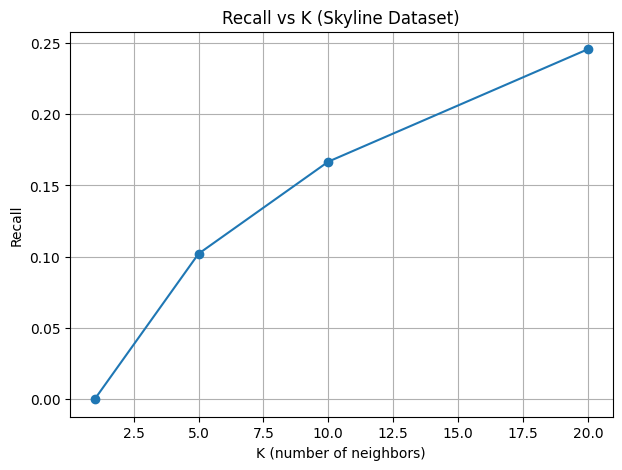

In [23]:
# -------------------------
# Recall vs K curve
# -------------------------

Ks = [1, 5, 10, 20]
recalls = []

for k in Ks:
    nbrs_k = index.knnQueryBatch(
        query_vectors,
        k=k,
        num_threads=threads
    )
    r = compute_recall(ground_truth, nbrs_k, k)
    recalls.append(r)
    print(f"Recall@{k}: {r:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(Ks, recalls, marker='o')
plt.xlabel("K (number of neighbors)")
plt.ylabel("Recall")
plt.title("Recall vs K (Skyline Dataset)")
plt.grid(True)
plt.show()
